# Chapter 4 — Exercise 4

This exercise investigates the **curse of dimensionality** and why K-nearest
neighbors (KNN) can perform poorly when the number of predictors is large.

## (a)

For \(p=1\), observations are uniformly distributed on the interval \([0,1]\).

We use observations contained within 10% of the range of \(X\) closest to the
test observation.

Therefore, the fraction of available observations used is:

\[
0.10
\]

or:

\[
\boxed{10\%}
\]

---

## (b)

For \(p=2\), an observation must be within 10% of the range for both
\(X_1\) and \(X_2\).

Therefore, the proportion of observations contained in this region is:

\[
0.10 \times 0.10
\]

\[
=0.01
\]

Hence:

\[
\boxed{1\%}
\]

of the observations will be used.

---

## (c)

For \(p=100\), an observation must be within 10% of the range for every one
of the 100 predictors.

Therefore, the expected fraction of observations is:

\[
(0.10)^{100}
\]

\[
=10^{-100}
\]

Thus:

\[
\boxed{10^{-100}}
\]

of the available observations will be used.

This is an extremely small fraction.

---

## (d)

The results show that as the number of predictors increases, the fraction
of observations that are close to a given test observation decreases very
rapidly.

For example:

\[
p=1 \Rightarrow 10\%
\]

\[
p=2 \Rightarrow 1\%
\]

\[
p=100 \Rightarrow 10^{-100}
\]

Therefore, when \(p\) is large, there are very few training observations
that are genuinely close to any particular test observation.

This is known as the **curse of dimensionality** and is an important
disadvantage of KNN and other local methods.

---

## (e)

Suppose that we instead want a \(p\)-dimensional hypercube containing,
on average, 10% of the training observations.

Let \(l\) be the length of each side.

The fraction of observations contained in the hypercube is:

\[
l^p
\]

We want:

\[
l^p = 0.10
\]

Therefore:

\[
l=(0.10)^{1/p}
\]

### For \(p=1\)

\[
l=(0.10)^{1/1}
\]

\[
\boxed{l=0.10}
\]

### For \(p=2\)

\[
l=(0.10)^{1/2}
\]

\[
l\approx0.316
\]

Therefore:

\[
\boxed{l\approx0.316}
\]

### For \(p=100\)

\[
l=(0.10)^{1/100}
\]

\[
l\approx0.977
\]

Therefore:

\[
\boxed{l\approx0.977}
\]

### Conclusion

When there is only one predictor, we need a neighborhood covering only
10% of that predictor's range in order to contain 10% of the observations.

With two predictors, each side already needs to cover about 31.6% of the
range.

With 100 predictors, each side must cover approximately 97.7% of the
range.

Therefore, in high dimensions, a neighborhood must cover almost the entire
range of every predictor in order to contain even a modest fraction of the
training observations. This demonstrates the **curse of dimensionality**.

# Chapter 4 — Exercise 9

## (a)

The relationship between probability \(p\) and odds is:

\[
\text{Odds} = \frac{p}{1-p}
\]

We are given:

\[
\frac{p}{1-p} = 0.37
\]

Solving for \(p\):

\[
p = 0.37(1-p)
\]

\[
p = 0.37 - 0.37p
\]

\[
1.37p = 0.37
\]

\[
p = \frac{0.37}{1.37}
\]

\[
p \approx 0.270
\]

Therefore:

\[
\boxed{p \approx 27.0\%}
\]

So approximately **27% of people** with odds of 0.37 will actually default.

---

## (b)

We are given a probability of default of:

\[
p = 0.16
\]

The odds are:

\[
\text{Odds} = \frac{p}{1-p}
\]

Therefore:

\[
\text{Odds}
=
\frac{0.16}{1-0.16}
\]

\[
=
\frac{0.16}{0.84}
\]

\[
\approx 0.1905
\]

Therefore:

\[
\boxed{\text{Odds} \approx 0.19}
\]

Equivalently, the odds of default are approximately:

\[
\boxed{4:21}
\]

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from ISLP import load_data, confusion_table

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis as LDA,
    QuadraticDiscriminantAnalysis as QDA
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [36]:
Auto = load_data('Auto')

Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [37]:
#14(a) Create a binary variable mpg01 based on the median of mpg
mpg_median = Auto['mpg'].median()

mpg01 = (Auto['mpg'] > mpg_median).astype(int)

Auto['mpg01'] = mpg01

print("Median MPG:", mpg_median)
Auto[['mpg', 'mpg01']].head()

Median MPG: 22.75


,mpg,mpg01
name,,
chevrolet chevelle malibu,18.0,0
buick skylark 320,15.0,0
plymouth satellite,18.0,0
amc rebel sst,16.0,0
ford torino,17.0,0


In [38]:
Auto['mpg01'].value_counts()

mpg01
0    196
1    196
Name: count, dtype: int64

## Exercise 14(a)

A binary variable `mpg01` was created using the median value of `mpg`.

- `mpg01 = 1` if MPG is above the median.
- `mpg01 = 0` otherwise.

This converts fuel economy into a binary classification problem:
high MPG versus low MPG.

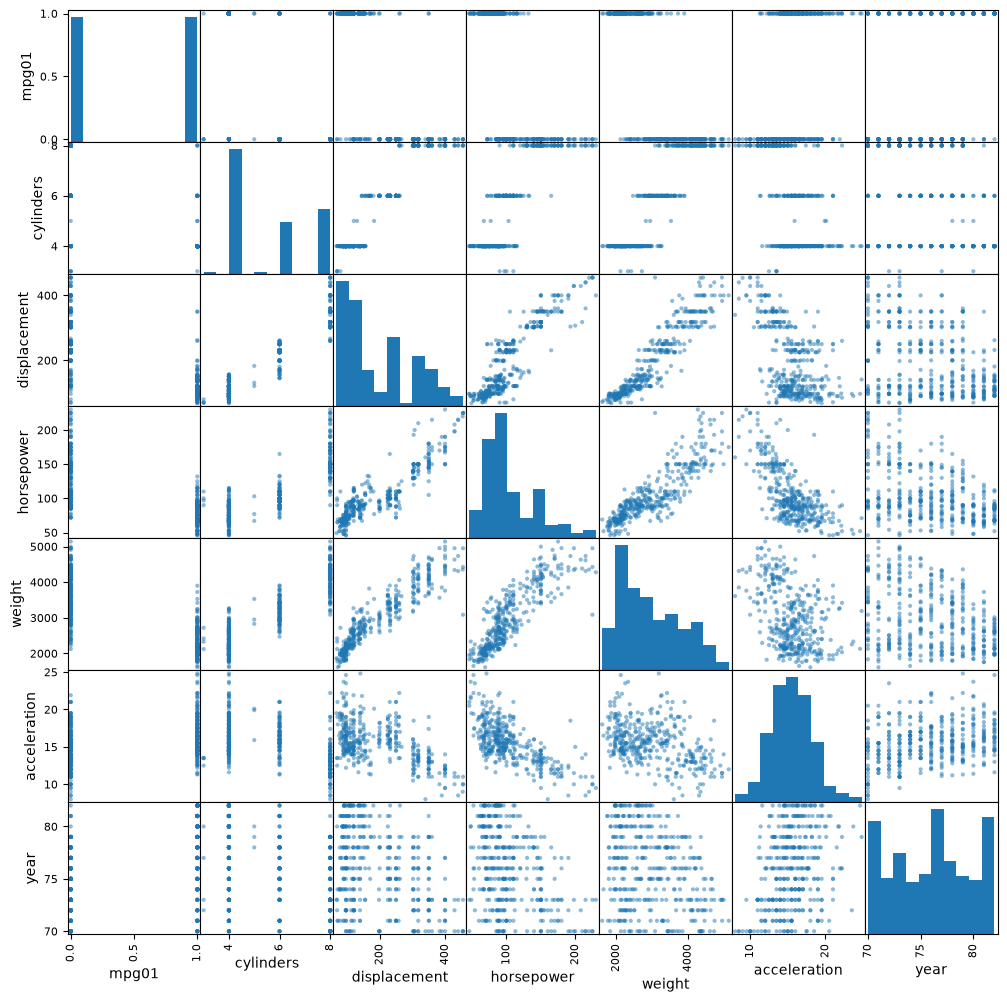

In [39]:
#14(b) Create a scatterplot matrix of the quantitative variables, colored by mpg01
pd.plotting.scatter_matrix(
    Auto[
        [
            'mpg01',
            'cylinders',
            'displacement',
            'horsepower',
            'weight',
            'acceleration',
            'year'
        ]
    ],
    figsize=(12, 12)
)

plt.show()

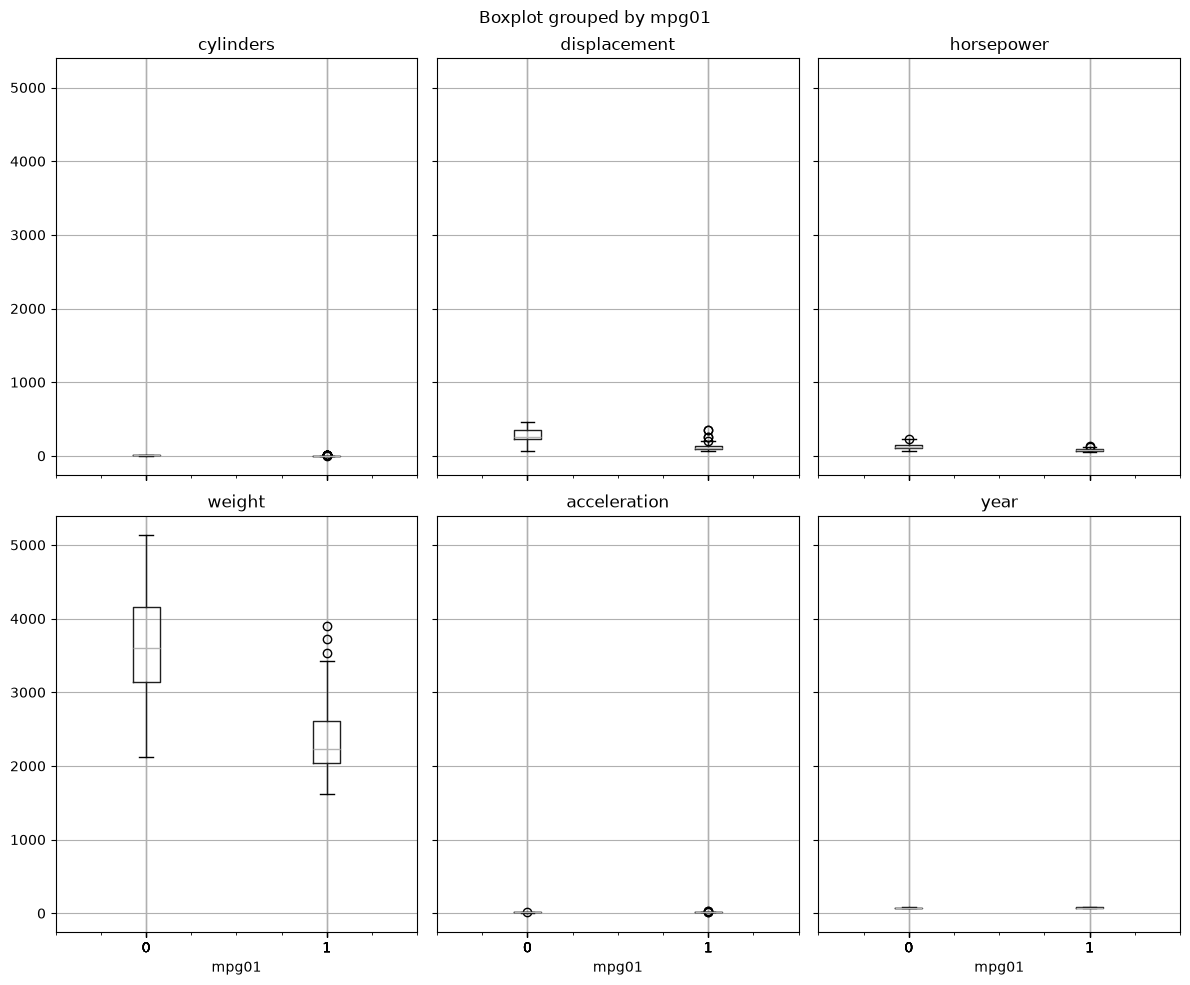

In [40]:
predictors_to_plot = [
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'year'
]

Auto.boxplot(
    column=predictors_to_plot,
    by='mpg01',
    figsize=(12, 10),
    layout=(2, 3)
)

plt.tight_layout()
plt.show()

## Exercise 14(b)

The graphical analysis suggests that the variables most strongly associated
with `mpg01` are:

- cylinders
- displacement
- horsepower
- weight
- year

Cars with high MPG generally have fewer cylinders, lower displacement,
lower horsepower and lower weight.

Model year also appears useful, since newer cars tend to have higher MPG.

Acceleration appears to have a weaker relationship with `mpg01`.

In [41]:
features = [
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'year'
]

In [42]:
#14(c) Training and test sets
X = Auto[features]
y = Auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=1,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Test observations:", X_test.shape[0])

Training observations: 196
Test observations: 196


In [43]:
#14(d) Linear Discriminant Analysis
lda = LDA()

lda.fit(X_train, y_train)

lda_pred = lda.predict(X_test)

confusion_table(lda_pred, y_test)

Truth,0,1
Predicted,,
0,84,5
1,14,93


In [44]:
lda_error = np.mean(lda_pred != y_test)

print("LDA test error:", lda_error)
print("LDA test accuracy:", 1 - lda_error)

LDA test error: 0.09693877551020408
LDA test accuracy: 0.903061224489796


In [45]:
#14(e) Quadratic Discriminant Analysis
qda = QDA()

qda.fit(X_train, y_train)

qda_pred = qda.predict(X_test)

confusion_table(qda_pred, y_test)

Truth,0,1
Predicted,,
0,86,11
1,12,87


In [46]:
qda_error = np.mean(qda_pred != y_test)

print("QDA test error:", qda_error)
print("QDA test accuracy:", 1 - qda_error)

QDA test error: 0.11734693877551021
QDA test accuracy: 0.8826530612244898


In [47]:
#14(f) Logistic Regression
X_train_logit = sm.add_constant(X_train)
X_test_logit = sm.add_constant(X_test)

glm = sm.GLM(
    y_train,
    X_train_logit,
    family=sm.families.Binomial()
)

glm_results = glm.fit()

glm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  mpg01   No. Observations:                  196
Model:                            GLM   Df Residuals:                      190
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -36.252
Date:                Thu, 27 Aug 2026   Deviance:                       72.503
Time:                        11:23:44   Pearson chi2:                     102.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6381
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -14.0241      6.409     -2.188      0.029     -26.585      -1.463
cylinders       -0.0952      0.571     -0.167      0.868      -1.215       1.024
displacement    -0.0277      0.016     -1.769      0.077      -0.058       0.003
horsepower      -0.0524      0.025     -2.066      0.039      -0.102      -0.003
weight          -0.0022      0.001     -1.606      0.108      -0.005       0.000
year             0.3979      0.100      3.965      0.000       0.201       0.595
================================================================================
"""

In [48]:
logit_prob = glm_results.predict(X_test_logit)

logit_pred = (logit_prob > 0.5).astype(int)

confusion_table(logit_pred, y_test)

Truth,0,1
Predicted,,
0,85,7
1,13,91


In [49]:
logit_error = np.mean(logit_pred != y_test)

print("Logistic Regression test error:", logit_error)
print("Logistic Regression test accuracy:", 1 - logit_error)

Logistic Regression test error: 0.10204081632653061
Logistic Regression test accuracy: 0.8979591836734694


In [50]:
#14(g) Naive Bayes
NB = GaussianNB()

NB.fit(X_train, y_train)

nb_pred = NB.predict(X_test)

confusion_table(nb_pred, y_test)

Truth,0,1
Predicted,,
0,84,8
1,14,90


In [51]:
nb_error = np.mean(nb_pred != y_test)

print("Naive Bayes test error:", nb_error)
print("Naive Bayes test accuracy:", 1 - nb_error)

Naive Bayes test error: 0.11224489795918367
Naive Bayes test accuracy: 0.8877551020408163


In [52]:
#14(h) K-Nearest Neighbors
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [53]:
knn_results = []

for K in [1, 3, 5, 7, 10, 20]:
    
    knn = KNeighborsClassifier(n_neighbors=K)
    
    knn.fit(X_train_std, y_train)
    
    knn_pred = knn.predict(X_test_std)
    
    test_error = np.mean(knn_pred != y_test)
    
    knn_results.append([K, test_error])
    
    print(f"K={K}: Test Error = {test_error:.4f}")

K=1: Test Error = 0.0765
K=3: Test Error = 0.0816
K=5: Test Error = 0.0918
K=7: Test Error = 0.1020
K=10: Test Error = 0.1122
K=20: Test Error = 0.1122


In [54]:
knn_results = pd.DataFrame(
    knn_results,
    columns=['K', 'Test Error']
)

knn_results

,K,Test Error
0,1,0.076531
1,3,0.081633
2,5,0.091837
3,7,0.102041
4,10,0.112245
5,20,0.112245


In [55]:
best_knn = knn_results.loc[
    knn_results['Test Error'].idxmin()
]

best_knn

K             1.000000
Test Error    0.076531
Name: 0, dtype: float64

In [56]:
results = pd.DataFrame({
    'Method': [
        'LDA',
        'QDA',
        'Logistic Regression',
        'Naive Bayes'
    ],
    'Test Error': [
        lda_error,
        qda_error,
        logit_error,
        nb_error
    ]
})

results

,Method,Test Error
0,LDA,0.096939
1,QDA,0.117347
2,Logistic Regression,0.102041
3,Naive Bayes,0.112245


### Exercise 14(d)–(g) — Model Results

Using cylinders, displacement, horsepower, weight, and year as predictors:

- **LDA test error:** 0.0969, or approximately **9.69%**
- **QDA test error:** 0.1173, or approximately **11.73%**
- **Logistic Regression test error:** 0.1020, or approximately **10.20%**
- **Naive Bayes test error:** 0.1122, or approximately **11.22%**

Among these four methods, **LDA provides the lowest test error** at approximately
9.69%, corresponding to a test accuracy of approximately 90.31%.

Logistic regression performs almost as well, with a test error of approximately
10.20%.

QDA has the highest test error among these four methods.

### Exercise 14(h) — KNN Results

The test errors obtained for different values of \(K\) were:

| K | Test Error |
|---:|---:|
| 1 | 0.0765 |
| 3 | 0.0816 |
| 5 | 0.0918 |
| 7 | 0.1020 |
| 10 | 0.1122 |
| 20 | 0.1122 |

The lowest test error is obtained when:

\[
K=1
\]

with a test error of approximately:

\[
\boxed{7.65\%}
\]

Therefore, among the KNN models considered, **K = 1 performs best**.

In [57]:
#15(a)
def Power():
    print(2**3)

Power()

8


In [58]:
#15(b)
def Power2(x, a):
    print(x**a)

Power2(3, 8)

6561


In [59]:
#15(c)
Power2(10, 3)
Power2(8, 17)
Power2(13, 13)

1000
2251799813685248
302875106592253


In [60]:
#15(d)
def Power3(x, a):
    result = x**a
    return result

In [61]:
Power3(3, 8)

6561

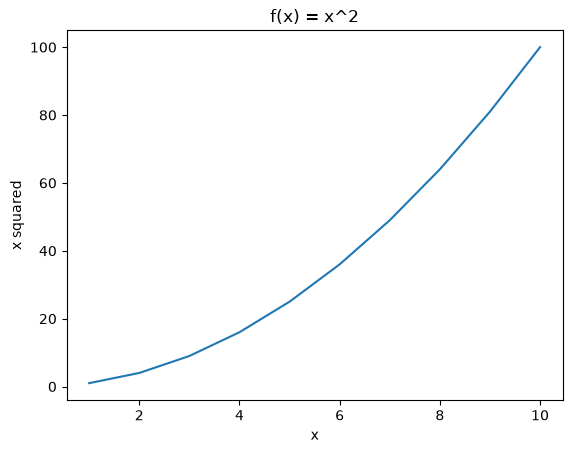

In [62]:
#15(e)
x = np.arange(1, 11)

y = Power3(x, 2)

fig, ax = plt.subplots()

ax.plot(x, y)

ax.set_xlabel('x')
ax.set_ylabel('x squared')
ax.set_title('f(x) = x^2')

plt.show()

In [63]:
#15(e)
def PlotPower(x, a):
    y = x**a

    fig, ax = plt.subplots()

    ax.plot(x, y)

    ax.set_xlabel('x')
    ax.set_ylabel(f'x^{a}')
    ax.set_title(f'x raised to the power {a}')

    plt.show()

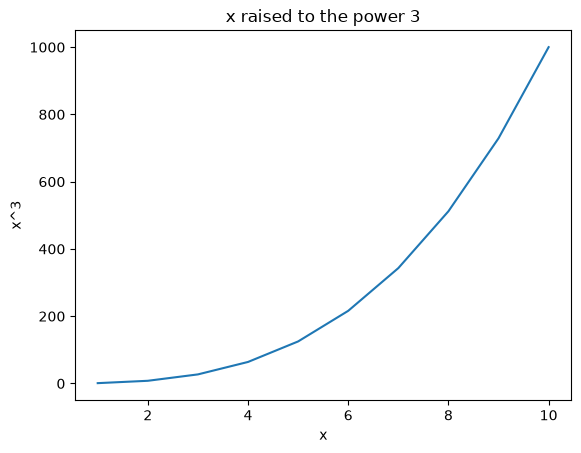

In [64]:
PlotPower(np.arange(1, 11), 3)